In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "rohiteng/amazon-sales-dataset"
)

csv_file = os.path.join(path, "Amazon.csv")

df = pd.read_csv(csv_file)

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Year']      = df['OrderDate'].dt.year
df['Month']     = df['OrderDate'].dt.month

# Texte
df['Country'] = df['Country'].str.title()
df['Category'] = df['Category'].str.title()

df.head(5)

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,1
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,12
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,5
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,7
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2


# Exploratory Data Analysis

In [3]:
print("=" * 60)
print("TÂCHE 1 — STATISTIQUES DESCRIPTIVES")
print("=" * 60)
 
num_cols = ['Quantity', 'UnitPrice', 'Discount', 'TotalAmount', 'ShippingCost']
print("\n── Statistiques numériques ──")
print(df[num_cols].describe().round(2).to_string())
 
print("\n── Statistiques catégorielles ──")
for col in ['Category', 'Country', 'OrderStatus', 'PaymentMethod']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())
 
print(f"\nNombre total de commandes : {len(df):,}")
print(f"Période                   : {df['OrderDate'].min().date()} → {df['OrderDate'].max().date()}")
print(f"Revenu total              : ${df['TotalAmount'].sum():,.2f}")
print(f"Panier moyen (AOV)        : ${df['TotalAmount'].mean():,.2f}")

TÂCHE 1 — STATISTIQUES DESCRIPTIVES

── Statistiques numériques ──
        Quantity  UnitPrice   Discount  TotalAmount  ShippingCost
count  100000.00  100000.00  100000.00    100000.00     100000.00
mean        3.00     302.91       0.07       918.26          7.41
std         1.41     171.84       0.08       724.51          4.32
min         1.00       5.00       0.00         4.27          0.00
25%         2.00     154.19       0.00       340.89          3.68
50%         3.00     303.07       0.05       714.32          7.30
75%         4.00     451.50       0.10      1349.76         11.15
max         5.00     599.99       0.30      3534.98         15.00

── Statistiques catégorielles ──

Category:
Category
Electronics          16853
Sports & Outdoors    16804
Books                16752
Home & Kitchen       16610
Toys & Games         16542
Clothing             16439

Country:
Country
United States     70058
India             15051
Canada             5818
United Kingdom     4943
Australia


===== ANALYSE DES DISTRIBUTIONS =====


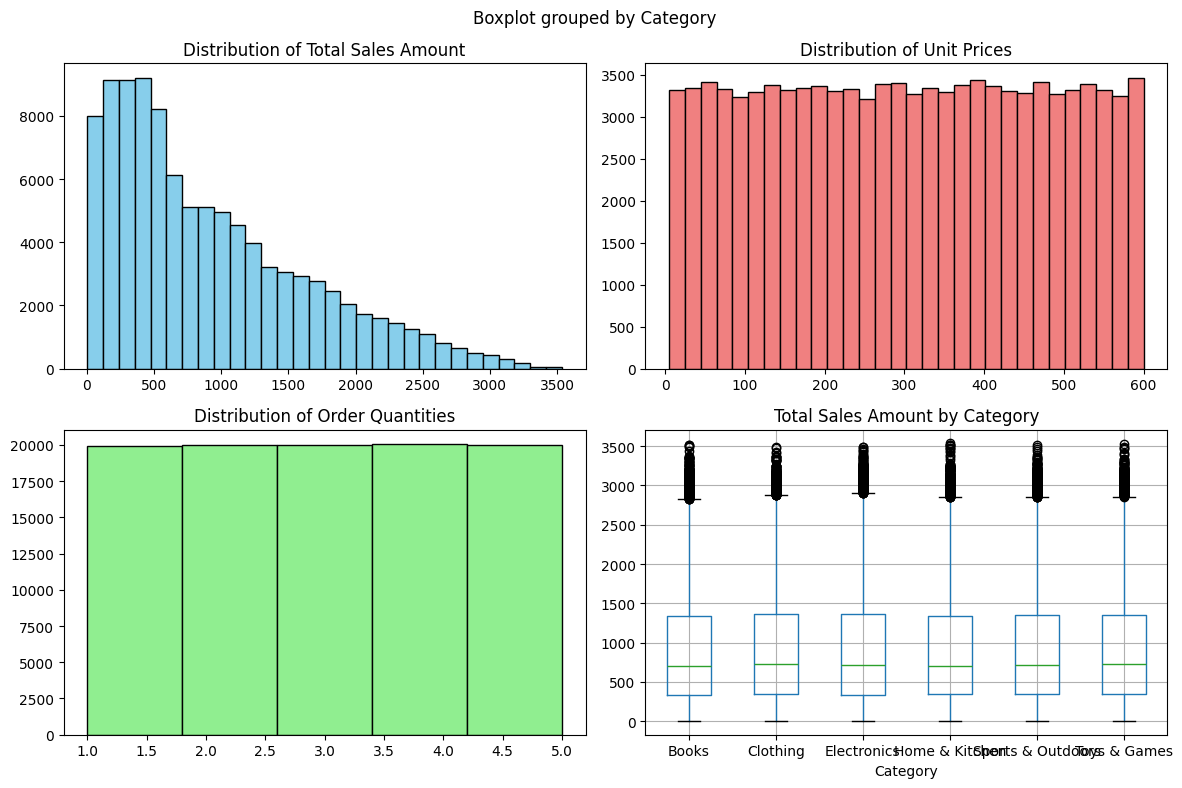

In [18]:
print("\n===== ANALYSE DES DISTRIBUTIONS =====")

# Création de 4 graphiques
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Distribution du montant total
axes[0,0].hist(df['TotalAmount'], bins=30, color='skyblue', edgecolor='black')
axes[0,0].set_title("Distribution of Total Sales Amount")

# 2. Distribution du prix unitaire
axes[0,1].hist(df['UnitPrice'], bins=30, color='lightcoral', edgecolor='black')
axes[0,1].set_title("Distribution of Unit Prices")

# 3. Distribution des quantités
axes[1,0].hist(df['Quantity'], bins=5, color='lightgreen', edgecolor='black')
axes[1,0].set_title("Distribution of Order Quantities")

# 4. Montant total par catégorie
df.boxplot(column='TotalAmount', by='Category', ax=axes[1,1])
axes[1,1].set_title("Total Sales Amount by Category")

plt.tight_layout()
plt.show()

1. Distribution of Total Sales Amount

Most orders have a low to medium total amount, while only a few orders have very high values. This indicates a right-skewed distribution.
______________
2. Distribution of Unit Prices

Unit prices are evenly distributed across the dataset, showing that products are available in different price ranges.
______________
3. Distribution of Order Quantities

Order quantities are evenly distributed between 1 and 5 items, indicating that customers purchase different quantities with no dominant value.
______________
4. Total Sales Amount by Category

All categories have a similar distribution of sales amounts. Several outliers are present, indicating that a few orders have exceptionally high sales values.


===== ANOMALIES & VALEURS MANQUANTES =====

Valeurs manquantes :
OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
Year             0
Month            0
dtype: int64

Doublons :
0


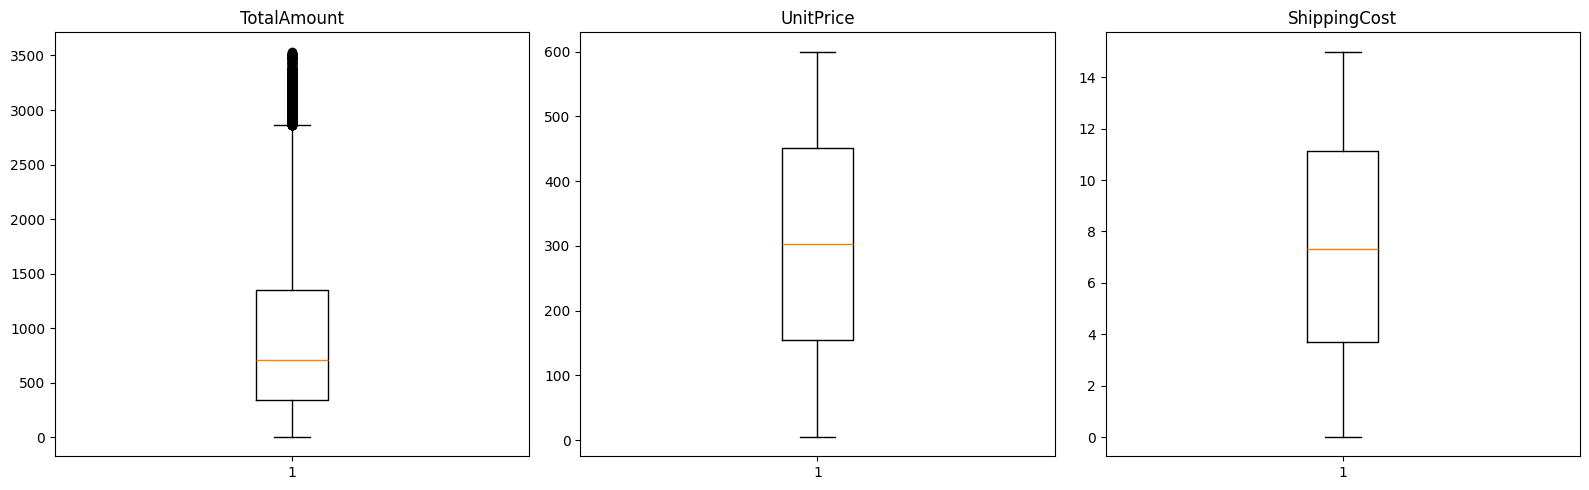


Valeurs incorrectes :
Montant <= 0 : 0
Quantité <= 0 : 0
Prix <= 0 : 0


In [5]:
print("\n===== ANOMALIES & VALEURS MANQUANTES =====")

# 1. Valeurs manquantes
print("\nValeurs manquantes :")
print(df.isnull().sum())

# 2. Doublons
print("\nDoublons :")
print(df.duplicated().sum())

# 3. Boxplots pour détecter les outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].boxplot(df['TotalAmount'])
axes[0].set_title("TotalAmount")

axes[1].boxplot(df['UnitPrice'])
axes[1].set_title("UnitPrice")

axes[2].boxplot(df['ShippingCost'])
axes[2].set_title("ShippingCost")

plt.tight_layout()
plt.show()

# 4. Vérification des valeurs incorrectes
print("\nValeurs incorrectes :")
print("Montant <= 0 :", (df['TotalAmount'] <= 0).sum())
print("Quantité <= 0 :", (df['Quantity'] <= 0).sum())
print("Prix <= 0 :", (df['UnitPrice'] <= 0).sum())


===== VISUALISATIONS EXPLORATOIRES =====


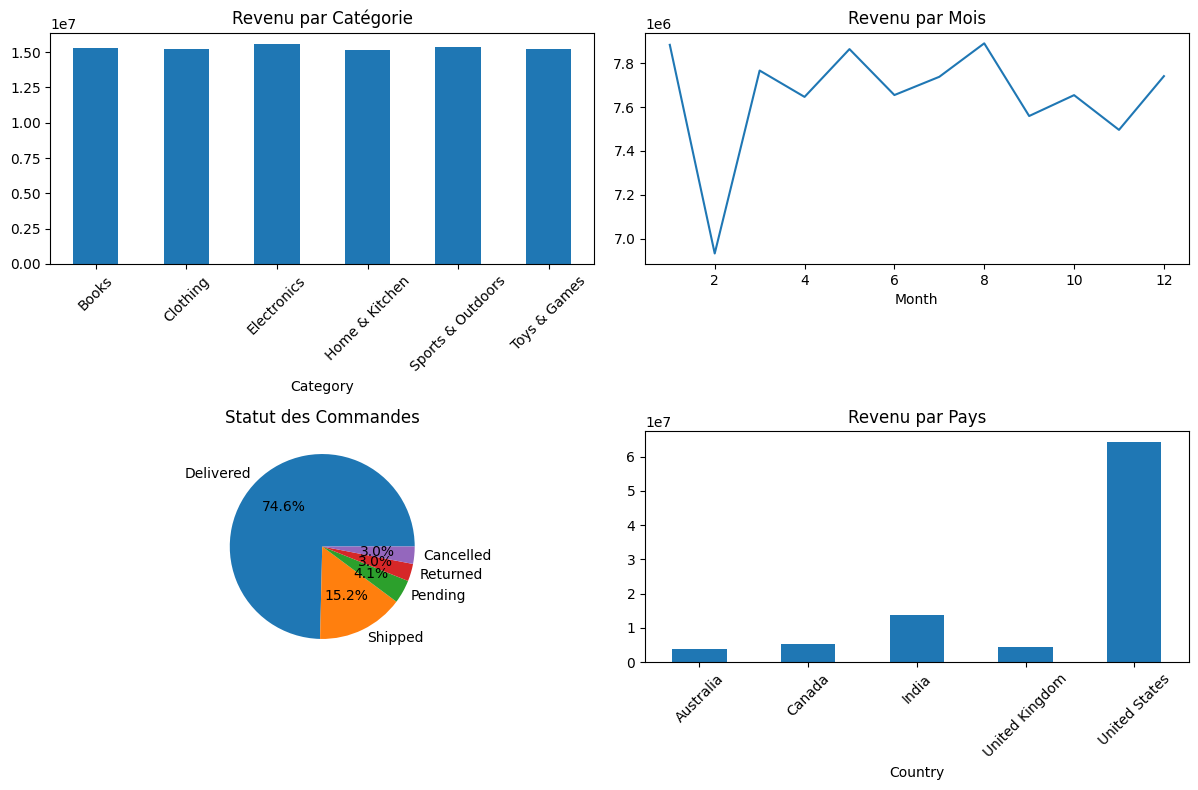

In [17]:
print("\n===== VISUALISATIONS EXPLORATOIRES =====")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Revenu par catégorie
df.groupby('Category')['TotalAmount'].sum().plot(
    kind='bar', ax=axes[0,0], rot=45
)
axes[0,0].set_title("Revenu par Catégorie")

# 2. Revenu par mois
df.groupby('Month')['TotalAmount'].sum().plot(
    ax=axes[0,1]
)
axes[0,1].set_title("Revenu par Mois")

# 3. Statut des commandes
df['OrderStatus'].value_counts().plot(
    kind='pie', ax=axes[1,0], autopct='%1.1f%%'
)
axes[1,0].set_title("Statut des Commandes")

# 4. Revenu par pays
df.groupby('Country')['TotalAmount'].sum().plot(
    kind='bar', ax=axes[1,1], rot=45
)
axes[1,1].set_title("Revenu par Pays")

plt.tight_layout()
plt.show()

1. Revenue by Category

This chart shows the total revenue for each product category. Electronics generates the highest revenue, while Home & Kitchen has the lowest. Overall, all categories perform similarly.
_____________________________
2. Revenue by Month

This chart shows monthly revenue. Sales are stable during the year, with the highest revenue in August and the lowest in February.
_____________________________
3. Order Status

This chart shows the distribution of order statuses. About 75% of orders are delivered, while cancelled and returned orders represent only a small percentage.
_____________________________
4. Revenue by Country

This chart compares revenue by country. The United States generates the highest revenue, followed by India. The other countries contribute much less.

In [7]:
print("\n===== PREMIERS INSIGHTS =====")

# KPIs principaux
print("Revenu Total :", round(df['TotalAmount'].sum(), 2))
print("Panier Moyen :", round(df['TotalAmount'].mean(), 2))

# Catégorie la plus rentable
top_categorie = df.groupby('Category')['TotalAmount'].sum().idxmax()
print("Top Catégorie :", top_categorie)

# Pays le plus rentable
top_pays = df.groupby('Country')['TotalAmount'].sum().idxmax()
print("Top Pays :", top_pays)

# Taux d'annulation
taux_annulation = (df['OrderStatus'] == 'Cancelled').mean() * 100
print("Taux d'annulation :", round(taux_annulation, 2), "%")

# Taux de retour
taux_retour = (df['OrderStatus'] == 'Returned').mean() * 100
print("Taux de retour :", round(taux_retour, 2), "%")


===== PREMIERS INSIGHTS =====
Revenu Total : 91825647.92
Panier Moyen : 918.26
Top Catégorie : Electronics
Top Pays : United States
Taux d'annulation : 3.03 %
Taux de retour : 3.05 %


#  Cleaning, preparation and modeling # 

In [8]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

# Supprimer les lignes contenant des valeurs manquantes
df = df.dropna()

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
Year             0
Month            0
dtype: int64


In [9]:
# Nombre de doublons
print(df.duplicated().sum())

# Supprimer les doublons
df = df.drop_duplicates()

0


#  Statistical analysis #

In [10]:
# ============================================================
# TEST 1 — T-TEST
# ============================================================
# Question:
# Is the average order value different between
# delivered orders and cancelled orders?
#
# H0 (Null Hypothesis):
# There is no difference between the two groups.
# ============================================================

print("="*55)
print("TEST 1 — T-TEST")
print("="*55)

delivered = df[df['OrderStatus'] == 'Delivered']['TotalAmount']
cancelled = df[df['OrderStatus'] == 'Cancelled']['TotalAmount']

t, p = stats.ttest_ind(delivered, cancelled)

print(f"\n  Average Delivered Orders : ${delivered.mean():.2f}")
print(f"  Average Cancelled Orders : ${cancelled.mean():.2f}")
print(f"  P-value                  : {p:.4f}")

if p < 0.05:
    print("\n  ✅ Significant Difference (p < 0.05)")
    print("  → Delivered and cancelled orders have different average amounts")
else:
    print("\n  ❌ No Significant Difference (p > 0.05)")
    print("  → Order amount does not influence whether an order is delivered or cancelled")

TEST 1 — T-TEST

  Average Delivered Orders : $916.18
  Average Cancelled Orders : $941.59
  P-value                  : 0.0584

  ❌ No Significant Difference (p > 0.05)
  → Order amount does not influence whether an order is delivered or cancelled


In [11]:
# ============================================================
# TEST 2 — CHI-SQUARE TEST
# ============================================================
# Question:
# Does the payment method influence
# the order status?
#
# H0 (Null Hypothesis):
# No relationship exists between the two variables.
# ============================================================

print("\n" + "="*55)
print("TEST 2 — CHI-SQUARE TEST")
print("="*55)

# Create a contingency table:
# Payment Method × Order Status
tableau = pd.crosstab(df['PaymentMethod'], df['OrderStatus'])

print("\nContingency Table:")
print(tableau)

chi2, p, dof, _ = stats.chi2_contingency(tableau)

print(f"\n  Chi²    : {chi2:.4f}")
print(f"  P-value : {p:.4f}")

if p < 0.05:
    print("\n  ✅ Significant Relationship (p < 0.05)")
    print("  → Payment method has a real impact on order status")
else:
    print("\n  ❌ No Significant Relationship (p > 0.05)")
    print("  → Payment method does not influence order status")



TEST 2 — CHI-SQUARE TEST

Contingency Table:
OrderStatus       Cancelled  Delivered  Pending  Returned  Shipped
PaymentMethod                                                     
Amazon Pay              461      11251      585       472     2248
Cash on Delivery        156       3633      196       143      800
Credit Card            1083      26073     1471      1075     5336
Debit Card              593      14917      832       609     3073
Net Banking             291       7406      417       313     1500
UPI                     444      11348      602       437     2235

  Chi²    : 14.9937
  P-value : 0.7768

  ❌ No Significant Relationship (p > 0.05)
  → Payment method does not influence order status


In [12]:
# ============================================================
# TEST 3 — PEARSON CORRELATION
# ============================================================
# Question:
# Is there a relationship between
# Discount and TotalAmount?
#
# Correlation coefficient (r):
#   r close to  1  → strong positive relationship
#   r close to -1  → strong negative relationship
#   r close to  0  → no relationship
# ============================================================

print("\n" + "="*55)
print("TEST 3 — PEARSON CORRELATION")
print("="*55)

r, p = stats.pearsonr(df['Discount'], df['TotalAmount'])

print(f"\n  Correlation Coefficient (r) : {r:.4f}")
print(f"  P-value                    : {p:.4f}")

if p < 0.05:
    print("\n  ✅ Significant Correlation (p < 0.05)")
    
    if r > 0:
        print(f"  → As discount increases, total amount also increases (r = {r:.4f})")
    else:
        print(f"  → As discount increases, total amount decreases (r = {r:.4f})")

else:
    print("\n  ❌ No Significant Correlation")
    print("  → Discount has no measurable impact on total amount")


TEST 3 — PEARSON CORRELATION

  Correlation Coefficient (r) : -0.1081
  P-value                    : 0.0000

  ✅ Significant Correlation (p < 0.05)
  → As discount increases, total amount decreases (r = -0.1081)


In [13]:
df.to_csv("amazon_clean.csv", index=False)